In [7]:
import pandas as pd

In [8]:
df=pd.read_csv("stock_analysis_100.csv")

In [9]:
df

,Date,Open,High,Low,Close,Volume
0,2026-01-05,100.00,100.34,99.06,100.00,1035672
1,2026-01-06,99.15,100.87,97.93,99.85,610835
2,2026-01-07,99.60,102.35,99.35,101.12,760093
3,2026-01-08,100.91,104.43,99.89,103.99,850786
4,2026-01-09,103.49,104.70,102.45,103.65,857047
...,...,...,...,...,...,...
95,2026-05-18,87.80,88.30,85.11,85.49,1078468
96,2026-05-19,85.69,86.89,85.45,86.03,930836
97,2026-05-20,85.57,87.85,84.48,86.52,694413
98,2026-05-21,86.60,87.14,86.50,86.61,821449


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    100 non-null    object 
 1   Open    100 non-null    float64
 2   High    100 non-null    float64
 3   Low     100 non-null    float64
 4   Close   100 non-null    float64
 5   Volume  100 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 4.8+ KB


In [11]:
df["Date"]=pd.to_datetime(df["Date"])


In [12]:
df=df.sort_values("Date")

In [13]:
df["Daily_Returns"]=(df["Close"]-df["Open"])*100

In [14]:
df["MA_20"]=df["Close"].rolling(20).mean()

In [15]:
df["MA_50"]=df["Close"].rolling(50).mean()

In [16]:
df

,Date,Open,High,Low,Close,Volume,Daily_Returns,MA_20,MA_50
0,2026-01-05,100.00,100.34,99.06,100.00,1035672,0.0,NaN,NaN
1,2026-01-06,99.15,100.87,97.93,99.85,610835,70.0,NaN,NaN
2,2026-01-07,99.60,102.35,99.35,101.12,760093,152.0,NaN,NaN
3,2026-01-08,100.91,104.43,99.89,103.99,850786,308.0,NaN,NaN
4,2026-01-09,103.49,104.70,102.45,103.65,857047,16.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
95,2026-05-18,87.80,88.30,85.11,85.49,1078468,-231.0,87.9065,87.3316
96,2026-05-19,85.69,86.89,85.45,86.03,930836,34.0,87.6480,87.3552
97,2026-05-20,85.57,87.85,84.48,86.52,694413,95.0,87.4340,87.3546
98,2026-05-21,86.60,87.14,86.50,86.61,821449,1.0,87.2125,87.3434


In [17]:
import matplotlib.pyplot as plt

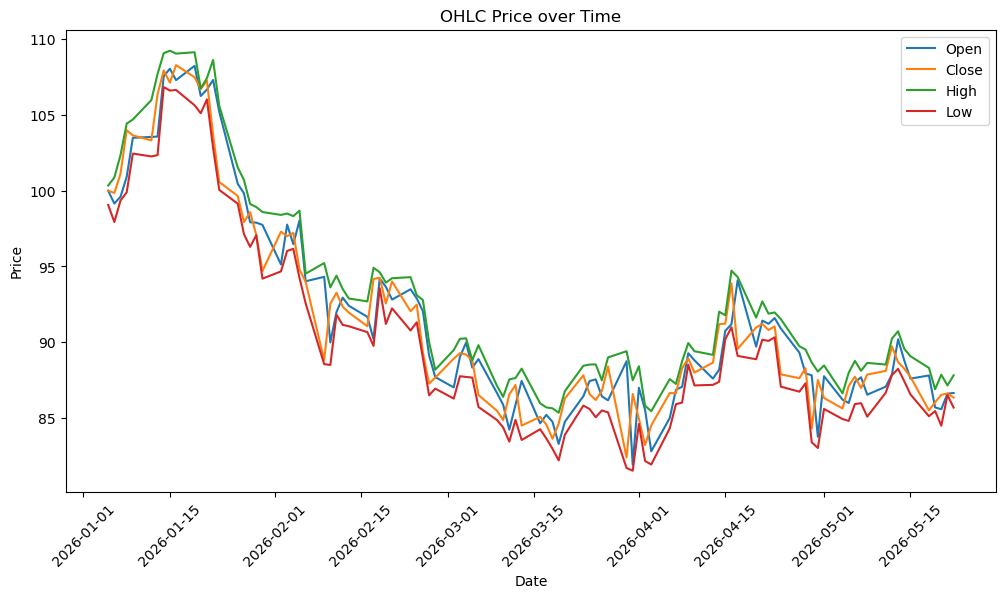

In [19]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"],df["Open"],label="Open")
plt.plot(df["Date"],df["Close"],label="Close")
plt.plot(df["Date"],df["High"],label="High")
plt.plot(df["Date"],df["Low"],label="Low")
plt.title("OHLC Price over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

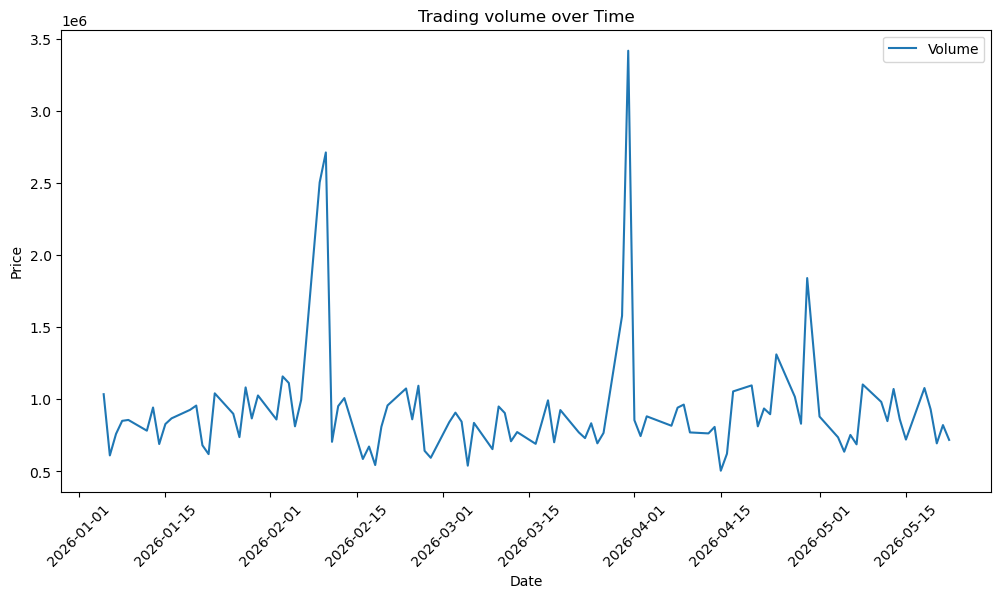

In [21]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"],df["Volume"],label="Volume")
plt.title("Trading volume over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

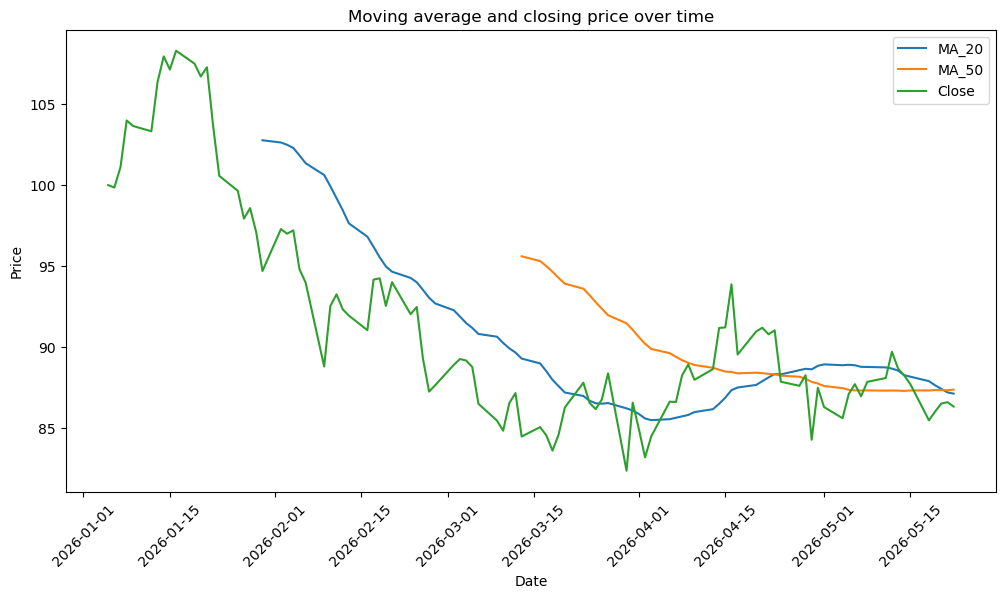

In [23]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"],df["MA_20"],label="MA_20")
plt.plot(df["Date"],df["MA_50"],label="MA_50")
plt.plot(df["Date"],df["Close"],label="Close")
plt.title("Moving average and closing price over time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [27]:
import seaborn as sns

##### plt.figure(figsize=(12, 6))

sns.histplot(df["Daily_Returns"], bins=8,kde=True)

plt.title("Distribution of Daily Return")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [31]:
Daily_return=df["Daily_Returns"]
avg_daily_return=Daily_return.mean()
variance=Daily_return.var()
std_deviation=Daily_return.std()
max_return=Daily_return.max()
min_return=Daily_return.min()

print("FINANCIAL SUMMARY")
print("-"*30)
print("AVERAGE DAILY RETURNS:",avg_daily_return)
print("VARIANCE:",variance)
print("STANDARD DEVIATION:",std_deviation)
print("MAXIMUM DAILY RETURN:",max_return)
print("MINIMUM DAILY RETURN:",min_return)

FINANCIAL SUMMARY
------------------------------
AVERAGE DAILY RETURNS: -15.479999999999963
VARIANCE: 38369.56525252522
STANDARD DEVIATION: 195.88150819443172
MAXIMUM DAILY RETURN: 467.99999999999926
MINIMUM DAILY RETURN: -636.0
